### Decision Tree Classifier

In [95]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score,roc_curve,auc

In [96]:
# Load dataset
df=pd.read_excel('heart_disease.xlsx')

In [97]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


##### Exploratory Data Analysis (EDA)

In [98]:
# dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [99]:
# check missing values
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [100]:
# statistical summary
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [101]:
# check for duplicate values
df.duplicated().sum()

np.int64(1)

In [102]:
df.drop_duplicates()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,normal,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,reversable defect,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,reversable defect,4


In [103]:
df.shape

(908, 13)

In [104]:
# select only numeric columns for outlier detection
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumeric Columns for Outlier Analysis:")
print(list(numeric_cols))


Numeric Columns for Outlier Analysis:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num']


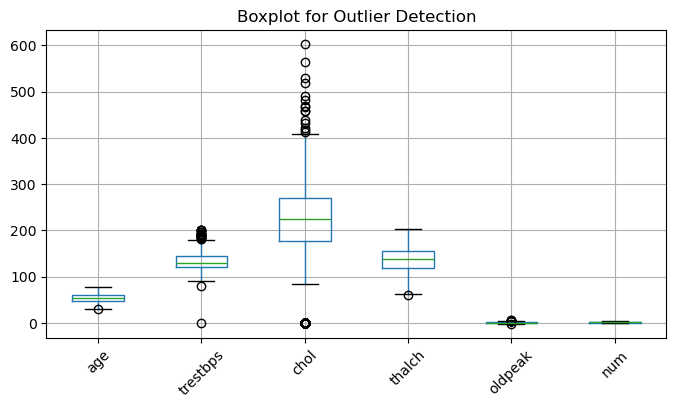

In [105]:
# check outliers using Boxplots
plt.figure(figsize=(8, 4))
df[numeric_cols].boxplot()
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.show()

In [106]:
# Detect Outliers Using IQR (Interquartile Range) Method
def detect_outliers_iqr(data):
    outlier_indices = {}
    for col in data.columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col]
        outlier_indices[col] = outliers.index.tolist()
    return outlier_indices

outlier_indices = detect_outliers_iqr(df[numeric_cols])
print("\nOutliers detected using IQR method:")
for col, indices in outlier_indices.items():
    print(f"{col}: {len(indices)} outliers")



Outliers detected using IQR method:
age: 1 outliers
trestbps: 22 outliers
chol: 187 outliers
thalch: 1 outliers
oldpeak: 16 outliers
num: 0 outliers


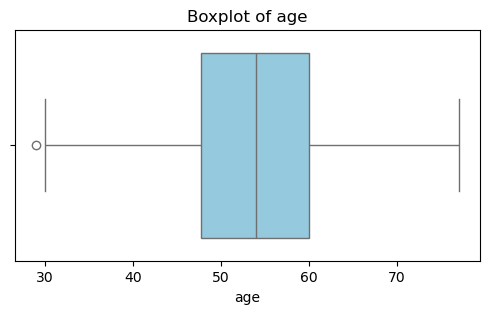

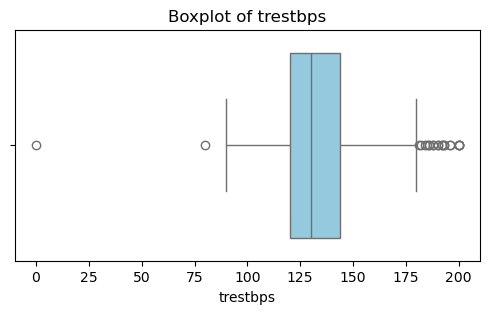

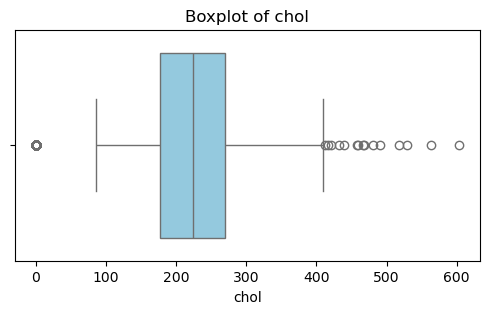

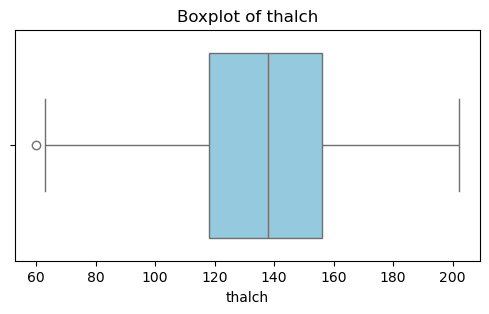

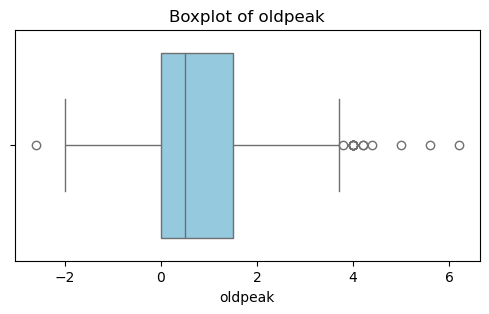

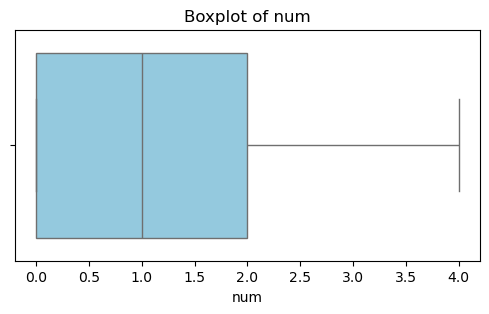

In [107]:
# visualize outliers for each numeric column
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f"Boxplot of {col}")
    plt.show()

In [108]:
# Remove outliers
df_no_outliers = df.drop(index=set(sum(outlier_indices.values(), [])))

# OR Cap (winsorize) outliers
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)


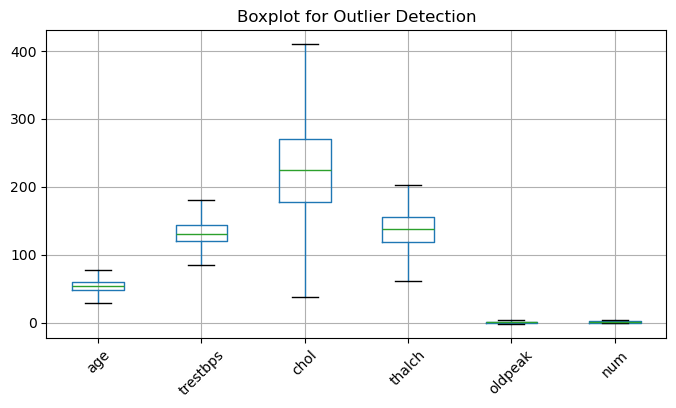

In [109]:
# check if outliers are removed
plt.figure(figsize=(8, 4))
df[numeric_cols].boxplot()
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.show()

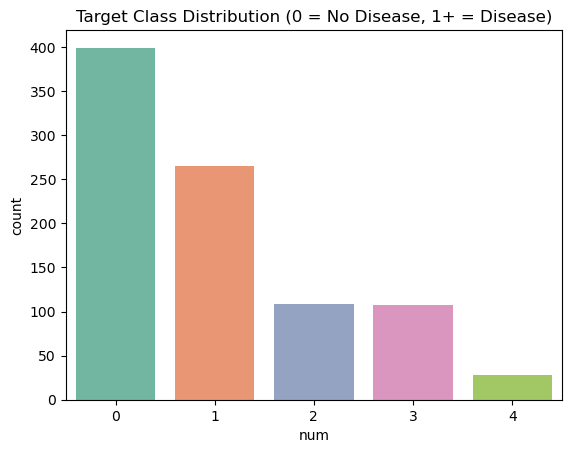

In [110]:
# Visualize class balance
sns.countplot(x='num', data=df, palette='Set2')
plt.title("Target Class Distribution (0 = No Disease, 1+ = Disease)")
plt.show()

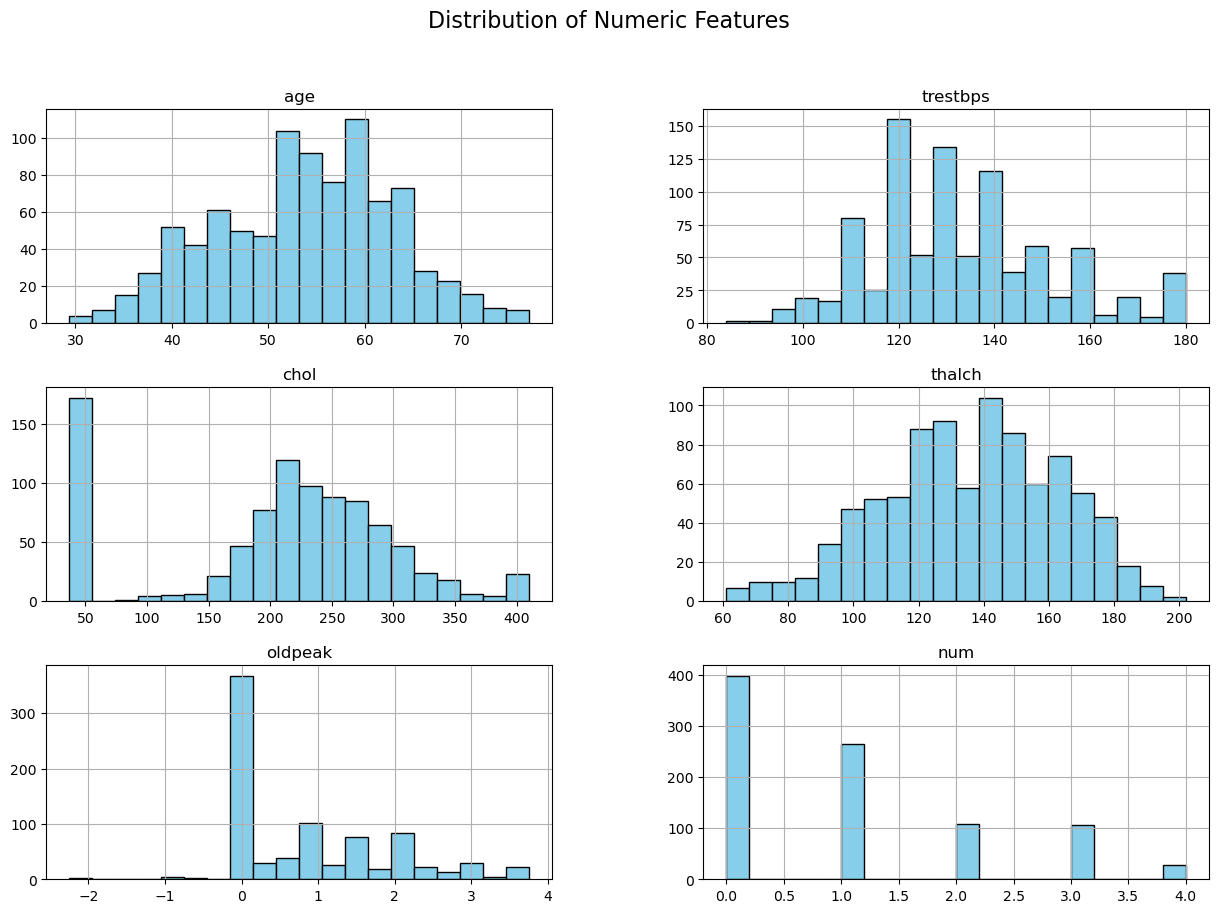

In [111]:
# histogram
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_cols].hist(figsize=(15, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.show()

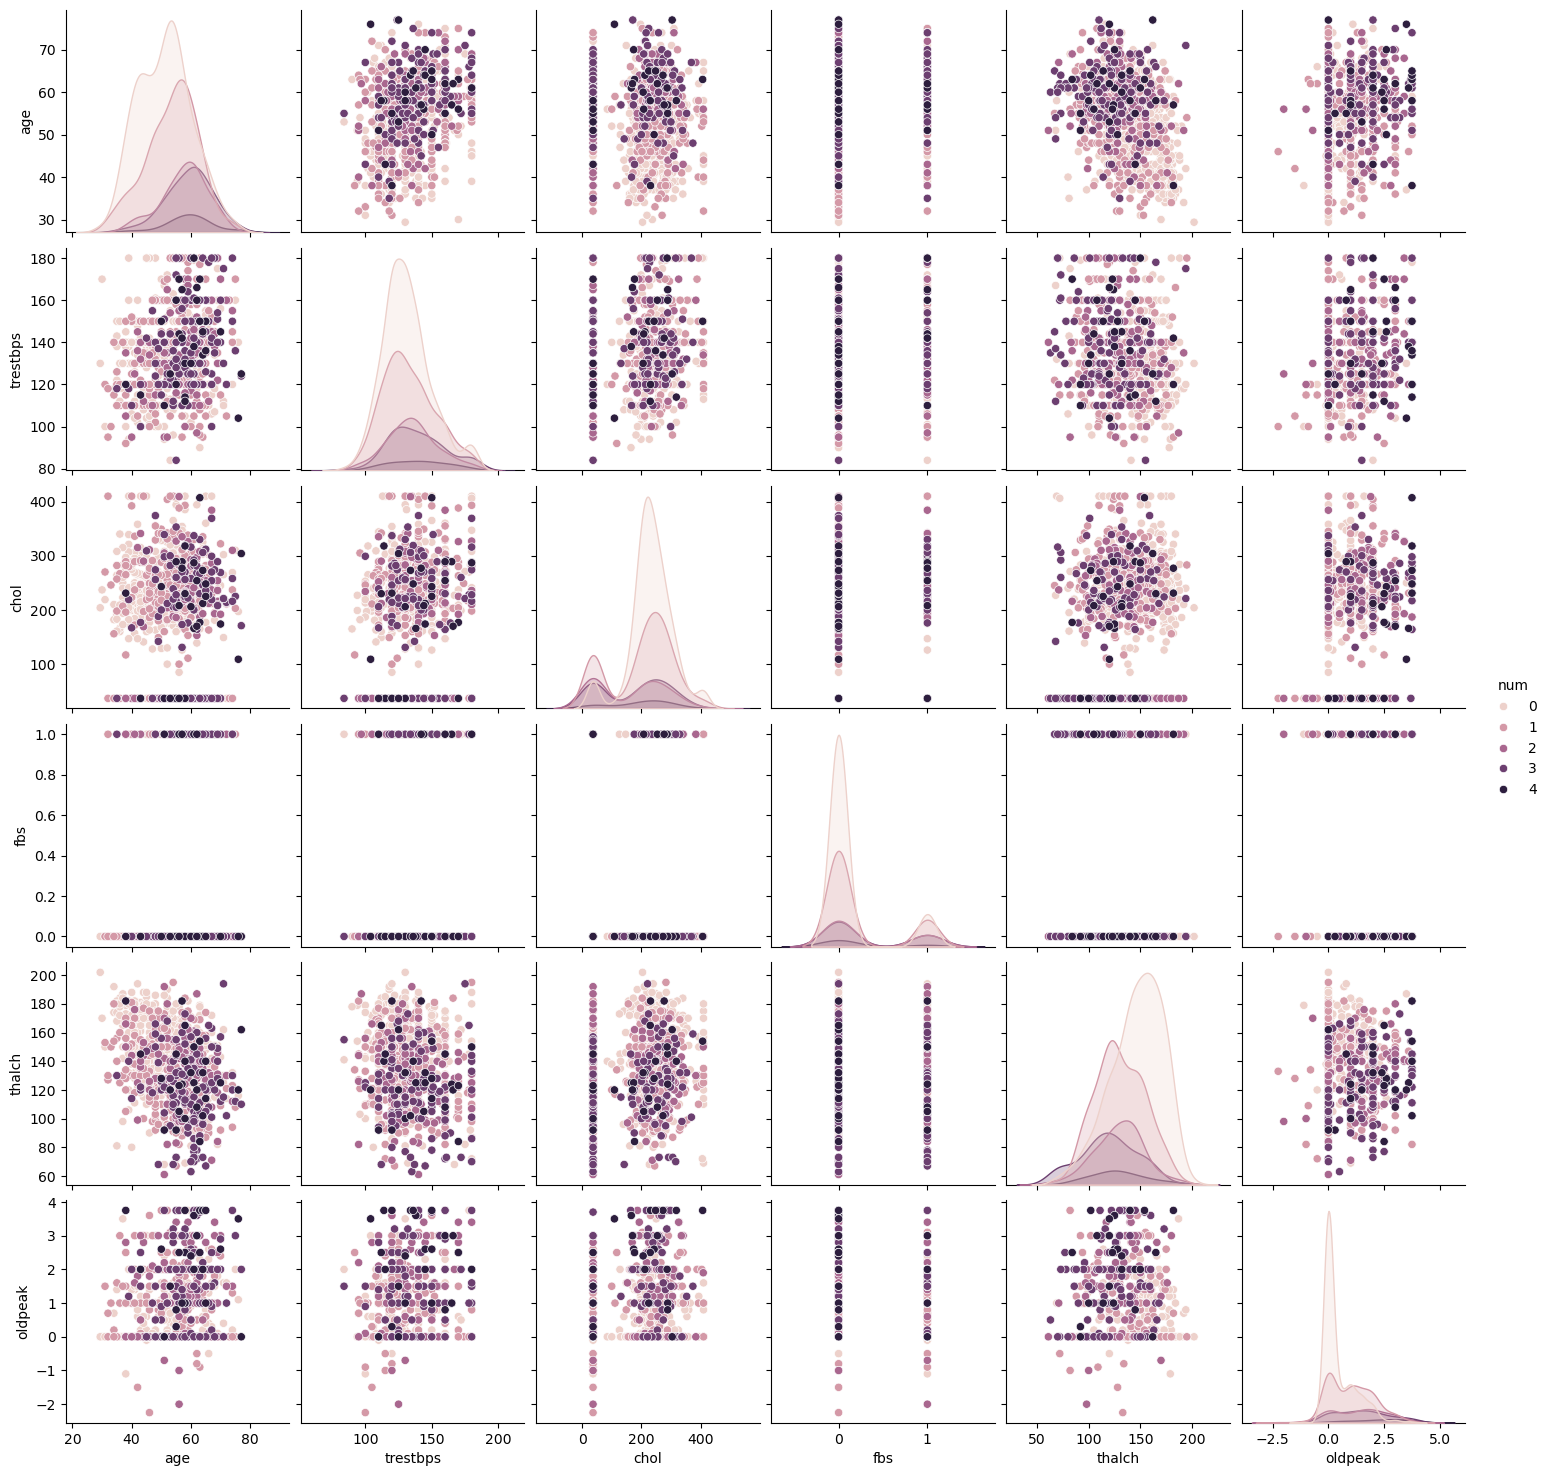

In [112]:
# pair plot
sns.pairplot(df, hue='num')
plt.show()

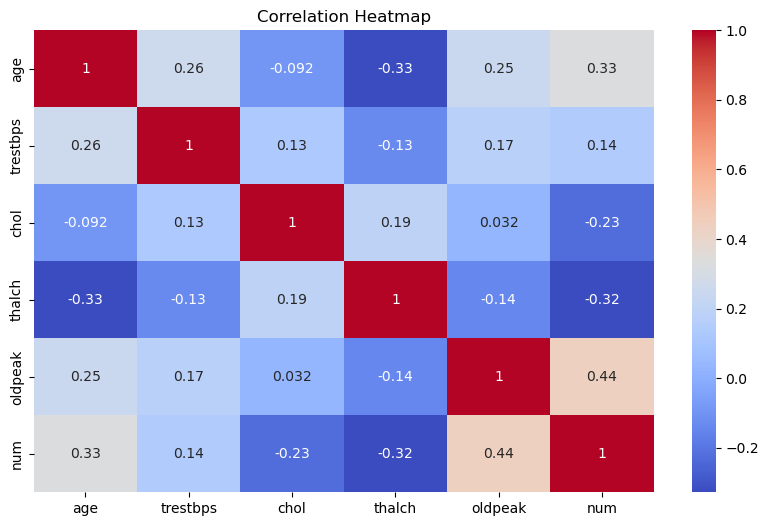

In [113]:
# Correlation Heatmap for numeric features
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##### Feature Engineering

In [114]:
# Convert categorical columns to numeric using Label Encoding
categorical_cols = ['sex', 'cp', 'restecg', 'slope', 'thal']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [115]:
# Ensure target column is binary (0 = No disease, 1 = Disease)
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

In [116]:
# Features (X) and Target (y)
X = df.drop('num', axis=1)
y = df['num']

# Convert categorical columns to numeric using one-hot encoding
X = pd.get_dummies(X)  

# scale the numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##### Split Dataset

In [117]:
# using 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nData Split Complete: {X_train.shape[0]} train, {X_test.shape[0]} test samples")


Data Split Complete: 726 train, 182 test samples


##### Train Decision Tree Classifier

In [118]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)


##### Evaluate Model

In [119]:
print("Decision Tree Performance\n")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Decision Tree Performance

Accuracy: 0.7197802197802198

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.70      0.69        80
           1       0.76      0.74      0.75       102

    accuracy                           0.72       182
   macro avg       0.72      0.72      0.72       182
weighted avg       0.72      0.72      0.72       182

Confusion Matrix:
 [[56 24]
 [27 75]]


In [121]:
# ROC-AUC Score and Curve
# Predict probabilities for the positive class
y_prob = dt.predict_proba(X_test)[:, 1]

In [123]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.7176470588235294


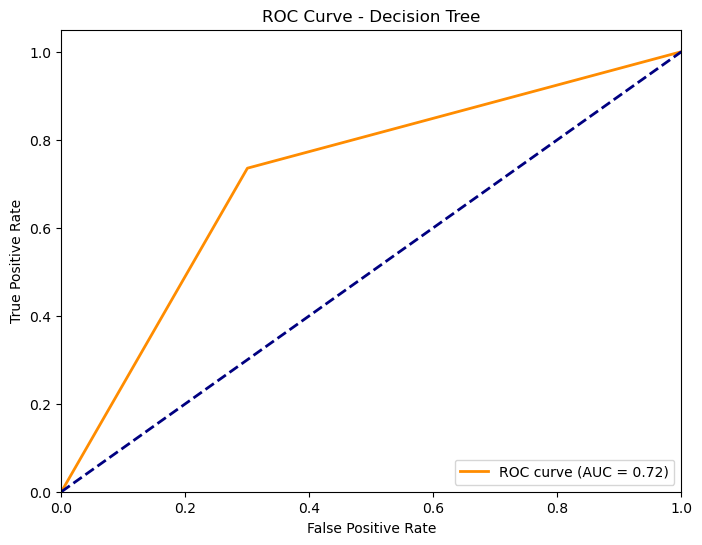

In [124]:
# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend(loc="lower right")
plt.show()

##### Hyperparameter Tuning (Grid Search)

In [125]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, None],
    'min_samples_split': [2, 3, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                           param_grid,
                           cv=5,
                           scoring='accuracy')

grid_search.fit(X_train, y_train)

print("\n Best Parameters Found:", grid_search.best_params_)
best_dt = grid_search.best_estimator_

# Evaluate tuned model
y_pred_best = best_dt.predict(X_test)
print("\n Tuned Model Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report (Tuned Model):\n", classification_report(y_test, y_pred_best))


 Best Parameters Found: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 2}

 Tuned Model Accuracy: 0.7637362637362637

Classification Report (Tuned Model):
               precision    recall  f1-score   support

           0       0.73      0.72      0.73        80
           1       0.79      0.79      0.79       102

    accuracy                           0.76       182
   macro avg       0.76      0.76      0.76       182
weighted avg       0.76      0.76      0.76       182



##### Visualize Decision Tree

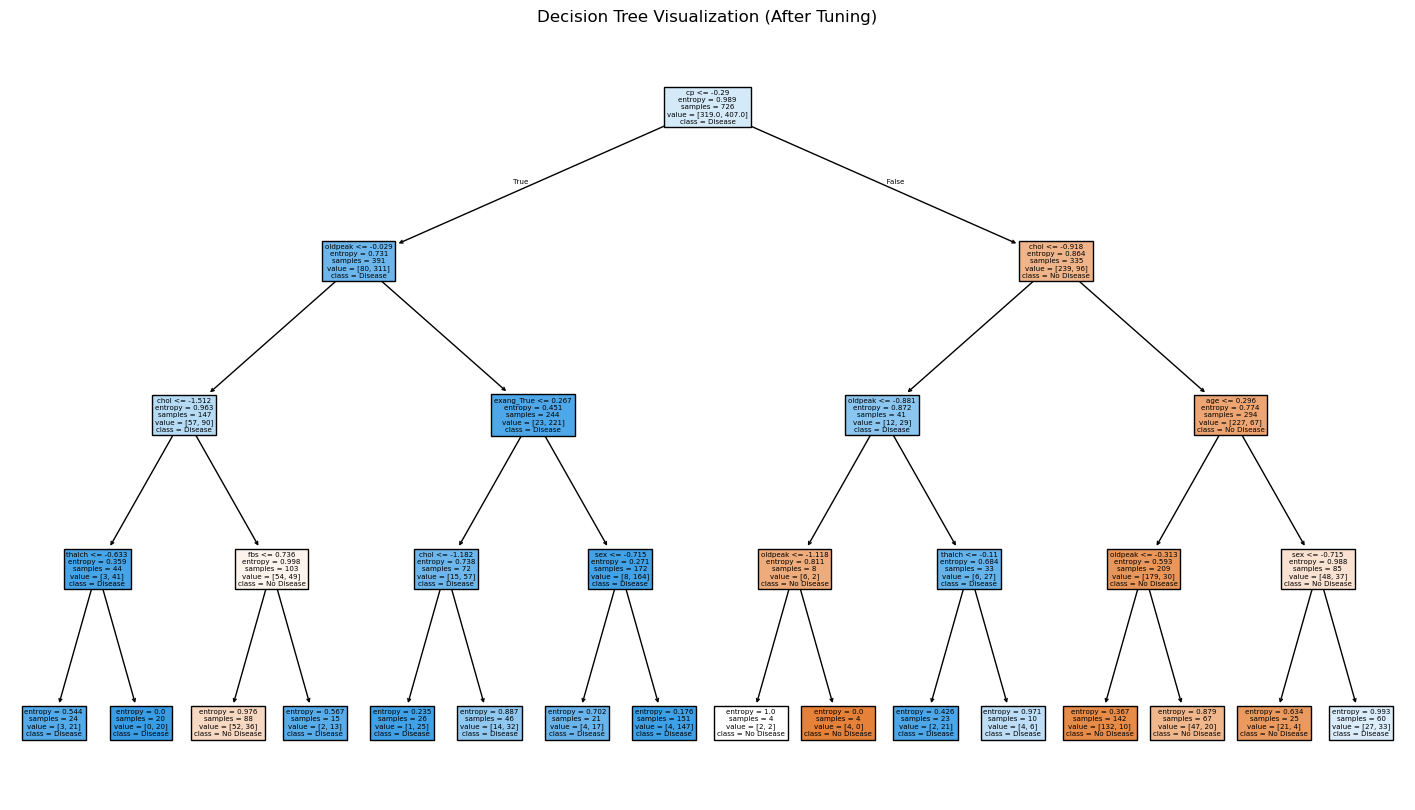

In [126]:
plt.figure(figsize=(18,10))
plot_tree(best_dt, filled=True, feature_names=X.columns, class_names=['No Disease', 'Disease'])
plt.title("Decision Tree Visualization (After Tuning)")
plt.show()

##### Feature Importance

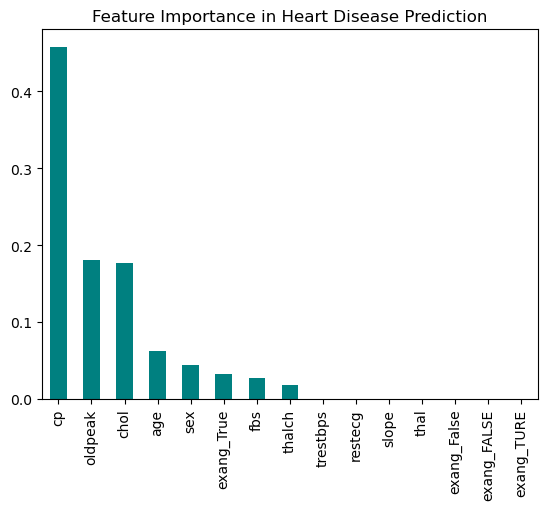

In [127]:
feat_importance = pd.Series(best_dt.feature_importances_, index=X.columns)
feat_importance.sort_values(ascending=False).plot(kind='bar', color='teal')
plt.title("Feature Importance in Heart Disease Prediction")
plt.show()


##### Interview Questions

1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

| **Hyperparameter**      | **Description**                                                                                                        | **Effect on Model Performance**                                                                                                           |
| ----------------------- | ---------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------- |
| **`criterion`**         | Function used to measure the quality of a split — commonly `'gini'` (Gini Impurity) or `'entropy'` (Information Gain). | Determines how the tree chooses the best split. Both usually give similar performance, but `'entropy'` can lead to slightly deeper trees. |
| **`max_depth`**         | Maximum depth (levels) of the tree.                                                                                    | Prevents overfitting. A smaller depth simplifies the model but may underfit; a larger depth captures more detail but can overfit.         |
| **`min_samples_split`** | Minimum number of samples required to split an internal node.                                                          | Higher value makes the model more conservative and prevents overfitting; too high may cause underfitting.                                 |
| **`min_samples_leaf`**  | Minimum number of samples required to be at a leaf node.                                                               | Ensures leaf nodes have enough samples; higher value smooths the model and reduces noise sensitivity.                                     |
| **`max_features`**      | Number of features to consider when looking for the best split.                                                        | Reduces variance and overfitting by limiting features per split. Useful in ensemble methods like Random Forest.                           |
| **`splitter`**          | Strategy used to choose the split at each node — `'best'` or `'random'`.                                               | `'best'` gives optimal split; `'random'` adds randomness, which can help generalization.                                                  |
| **`random_state`**      | Controls randomness for reproducibility.                                                                               | Ensures consistent results when the model is retrained.                                                                                   |


###### Summary:

* Large depth & small min_samples_split → Overfitting

* Shallow depth & large min_samples_split → Underfitting

* Tuning these hyperparameters finds the right bias-variance balance.

2. What is the difference between the Label encoding and One-hot encoding?

| **Aspect**         | **Label Encoding**                                                                                   | **One-Hot Encoding**                                                               |
| ------------------ | ---------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------- |
| **Definition**     | Converts each unique category into an integer value.                                                 | Creates binary (0/1) columns for each category.                                    |
| **Output Example** | `Red=0`, `Blue=1`, `Green=2`                                                                         | `Red=[1,0,0]`, `Blue=[0,1,0]`, `Green=[0,0,1]`                                     |
| **Use Case**       | When the categorical variable is **ordinal** (has a natural order), e.g., “Low”, “Medium”, “High”.   | When the variable is **nominal** (no natural order), e.g., “Red”, “Blue”, “Green”. |
| **Problem**        | The model might interpret numeric values as having order or magnitude, which can mislead algorithms. | Avoids order misinterpretation but increases dimensionality.                       |
| **Libraries**      | `LabelEncoder()` from `sklearn.preprocessing`                                                        | `OneHotEncoder()` or `pd.get_dummies()`                                            |


                                                           Submitted by: Meghana C Varghese